<a href="https://colab.research.google.com/github/NoraFlamez/Tugas-Fundamental-Data-Analyst/blob/main/Adriansyah_Tugas_P-4_Fundamental_Data_Analyst.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix, classification_report, roc_curve, roc_auc_score, precision_recall_curve

url = "https://raw.githubusercontent.com/NoraFlamez/Tugas-Fundamental-Data-Analyst/refs/heads/main/Student_performance_data%20_.csv"
columns_names = ['StudentID','Age','Gender','Ethnicity','ParentalEducation','StudyTimeWeekly','Absences','Tutoring','ParentalSupport','Extracurricular','Sports','Music','Volunteering','GPA','GradeClass']
data = pd.read_csv(url, names=columns_names)

# Hapus baris pertama yang kemungkinan merupakan header asli.
data = data.iloc[1:].copy()

# Konversi semua kolom menjadi numerik, memaksa kesalahan
for col in data.columns:
  data[col] = pd.to_numeric(data[col], errors='coerce')

# Hapus baris yang nilainya kosong
data.dropna(inplace=True)


Data Pertama:
   StudentID  Age  Gender  Ethnicity  ParentalEducation  StudyTimeWeekly  \
1       1001   17       1          0                  2        19.833723   
2       1002   18       0          0                  1        15.408756   
3       1003   15       0          2                  3         4.210570   
4       1004   17       1          0                  3        10.028829   
5       1005   17       1          0                  2         4.672495   

   Absences  Tutoring  ParentalSupport  Extracurricular  Sports  Music  \
1         7         1                2                0       0      1   
2         0         0                1                0       0      0   
3        26         0                2                0       0      0   
4        14         0                3                1       0      0   
5        17         1                3                0       0      0   

   Volunteering       GPA  GradeClass  
1             0  2.929196         2.0  
2   

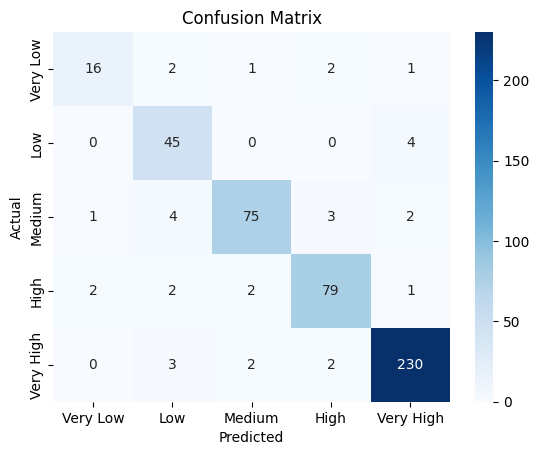

              precision    recall  f1-score   support

         0.0       0.84      0.73      0.78        22
         1.0       0.80      0.92      0.86        49
         2.0       0.94      0.88      0.91        85
         3.0       0.92      0.92      0.92        86
         4.0       0.97      0.97      0.97       237

    accuracy                           0.93       479
   macro avg       0.89      0.88      0.89       479
weighted avg       0.93      0.93      0.93       479



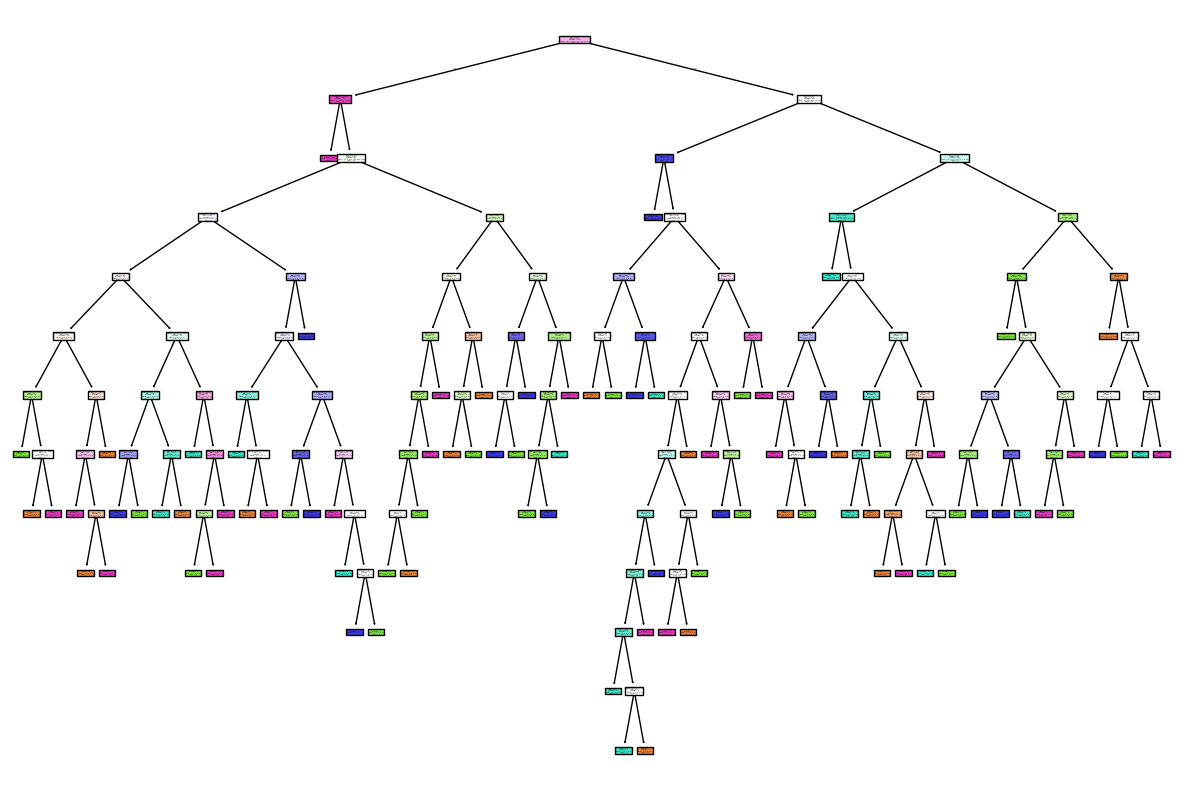

In [27]:
# Tampilkan data pertama
print("Data Pertama:")
print(data.head())

# Cek informasi dasar dataset
print("\nInformasi Dataset:")
print(data.info())

# Statistik deskriptif
print("\nStatistik Deskriptif:")
print(data.describe())

# Cek distribusi target
print("\nDistribusi Target:")
print(data['GradeClass'].value_counts())

# Pisahkan fitur (X) dan target (y)
X = data.drop('GradeClass', axis=1)
y = data['GradeClass']

# Membagi data menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Tampilkan ukuran data latih dan data uji
print(f"\nUkuran Data Latih: {X_train.shape}")
print(f"Ukuran Data Uji: {X_test.shape}")

# Membuat model Decision Tree
model = DecisionTreeClassifier(random_state=42)

# Melatih model
model.fit(X_train, y_train)

# Melakukan prediksi dengan data uji
y_pred = model.predict(X_test)

# Tampilkan hasil prediksi pertama
print("\nPrediksi Pertama:")
print(y_pred[:5])

# Menghitung akurasi
accuracy = accuracy_score(y_test, y_pred)
labels = ['Very Low','Low', 'Medium', 'High', 'Very High']
print(f"\nAkurasi Model: {accuracy:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Classification report (precision, recall, f1-score)
cr = classification_report(y_test, y_pred)
print("\nClassification Report:")
print(cr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()
# Tampilkan classification report
print(classification_report(y_test, y_pred))

# Plot pohon keputusan
plt.figure(figsize=(15, 10))
plot_tree(model, filled=True, feature_names=X.columns, class_names=['0.1','1.0', '2.0', '3.0', '4.0'])
plt.show()